# TITANIC DATASET COMPLETE EDA(VISUALIZATION) USING SEABORN

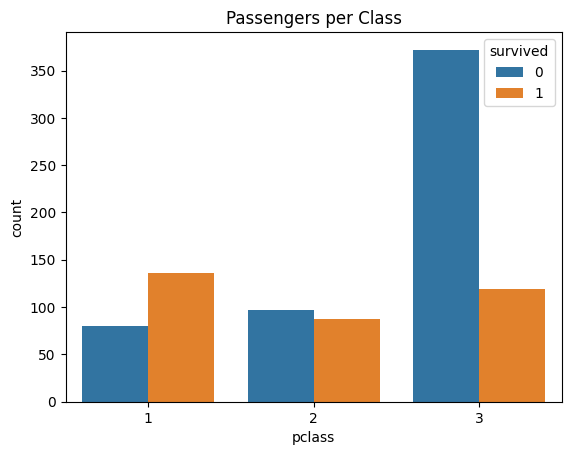

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

df = sns.load_dataset("titanic")
# df
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Passengers per Class')
plt.show()

C:\Temps\ipykernel_41724\3139707077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="pclass", palette="Blues")


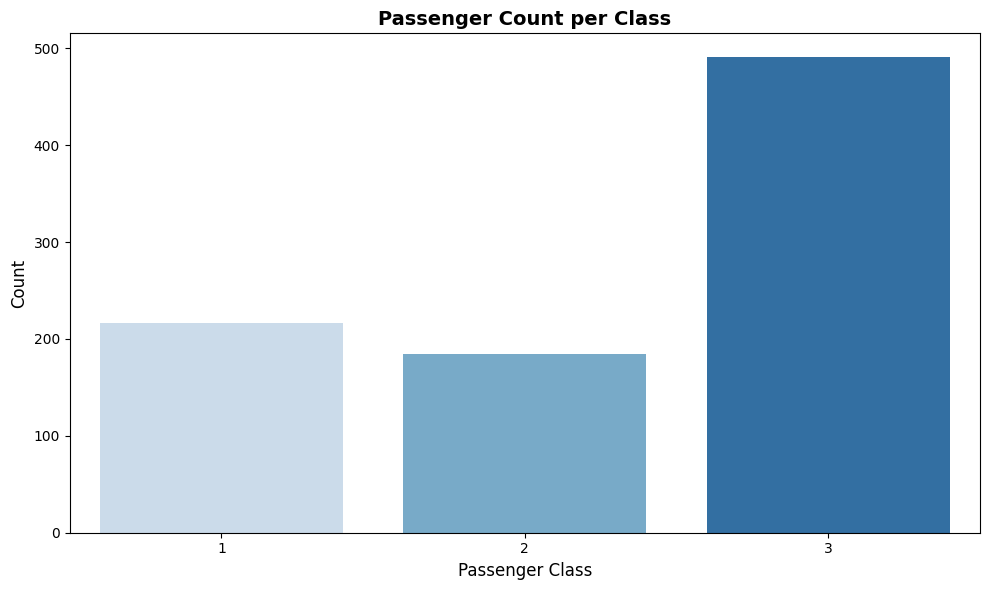

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="pclass", palette="Blues")

plt.title("Passenger Count per Class",
          fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# 📊 INSIGHT 1: Class 3 has most passengers
# 📊 INSIGHT 2: Class 1 and 2 combined 
#               still less than Class 3

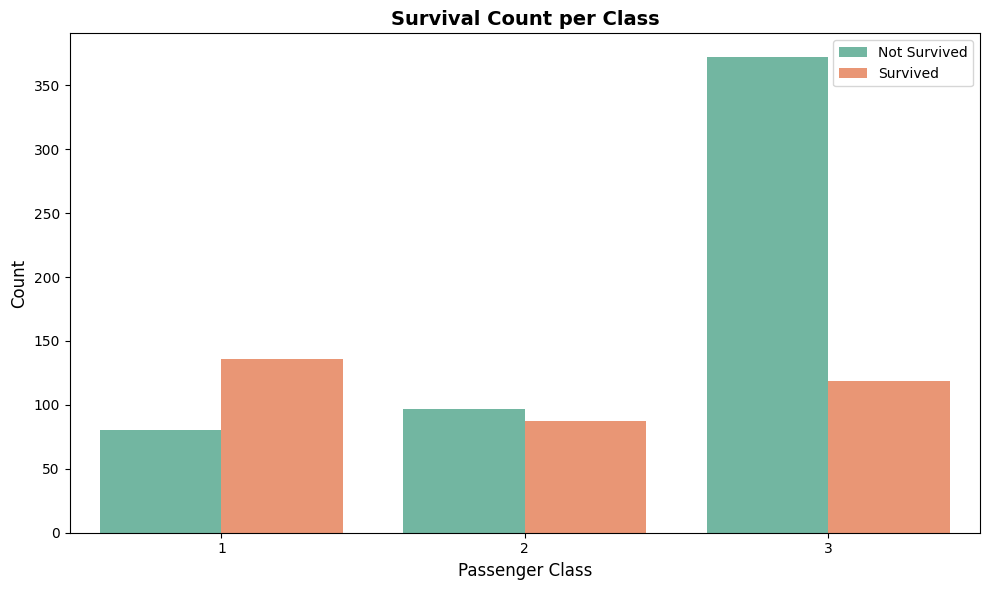

In [21]:
# Split survival by sex — ONE LINE
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="pclass",
              hue="survived",
              palette="Set2")

plt.title("Survival Count per Class",
          fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(["Not Survived", "Survived"])
plt.tight_layout()
plt.show()

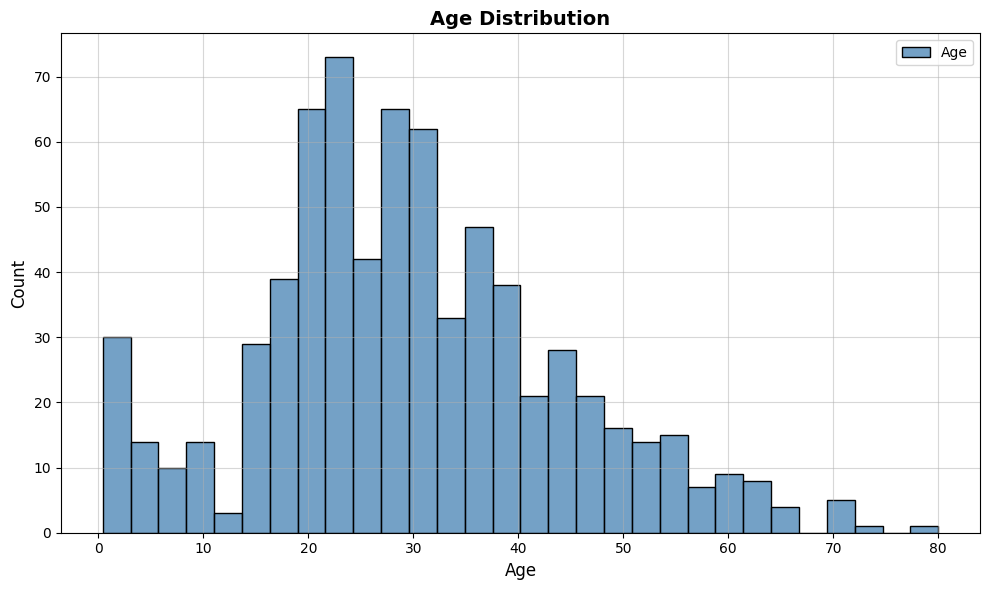

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age",
             bins=30,
            #  kde=True,          # adds smooth curve on top
             color="steelblue")

plt.title("Age Distribution",
          fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(alpha=0.5)
plt.legend(["Age"])

plt.tight_layout()
plt.show()

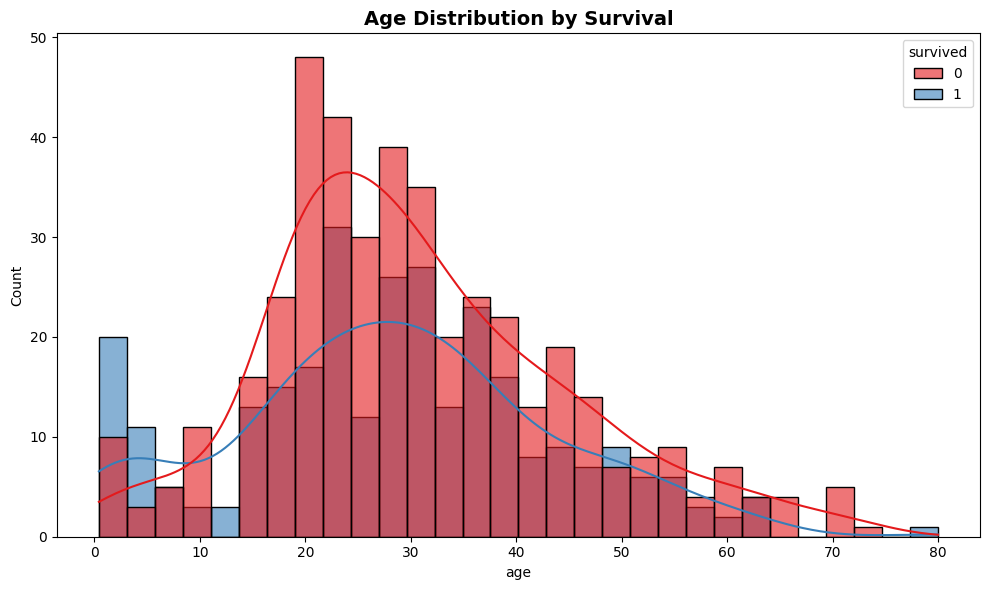

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age",
             hue="survived",    # split by survival
             bins=30,
             kde=True,
             palette="Set1",
             alpha=0.6)

plt.title("Age Distribution by Survival",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

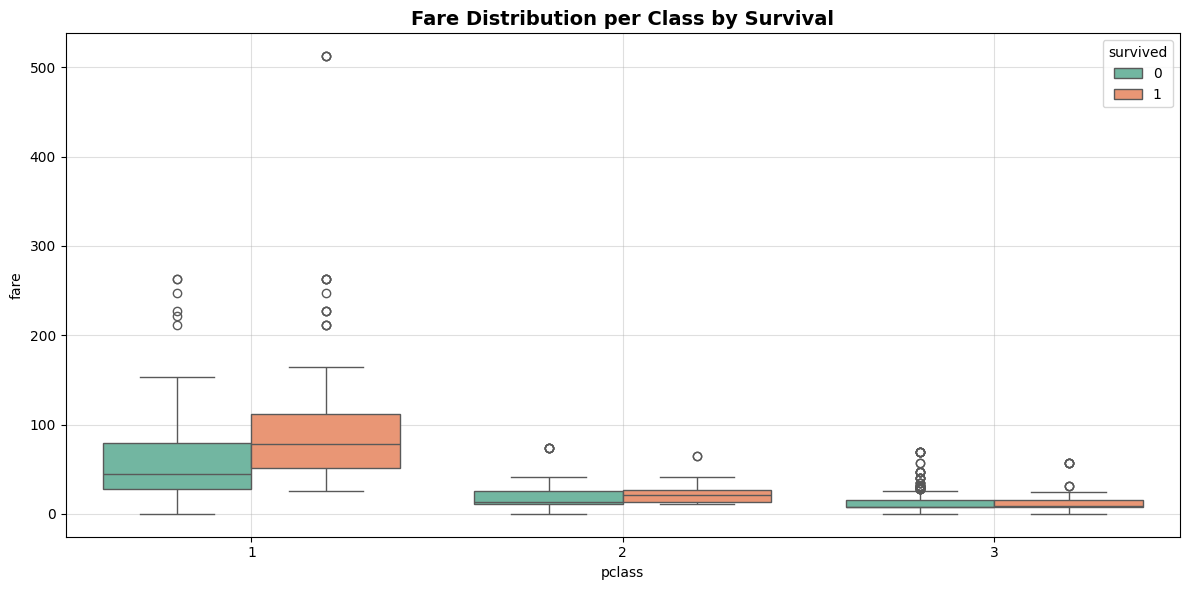

In [35]:
# With hue — compare survival within each class
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="pclass", y="fare",
            hue="survived",
            palette="Set2")

plt.title("Fare Distribution per Class by Survival",
          fontsize=14, fontweight="bold")
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

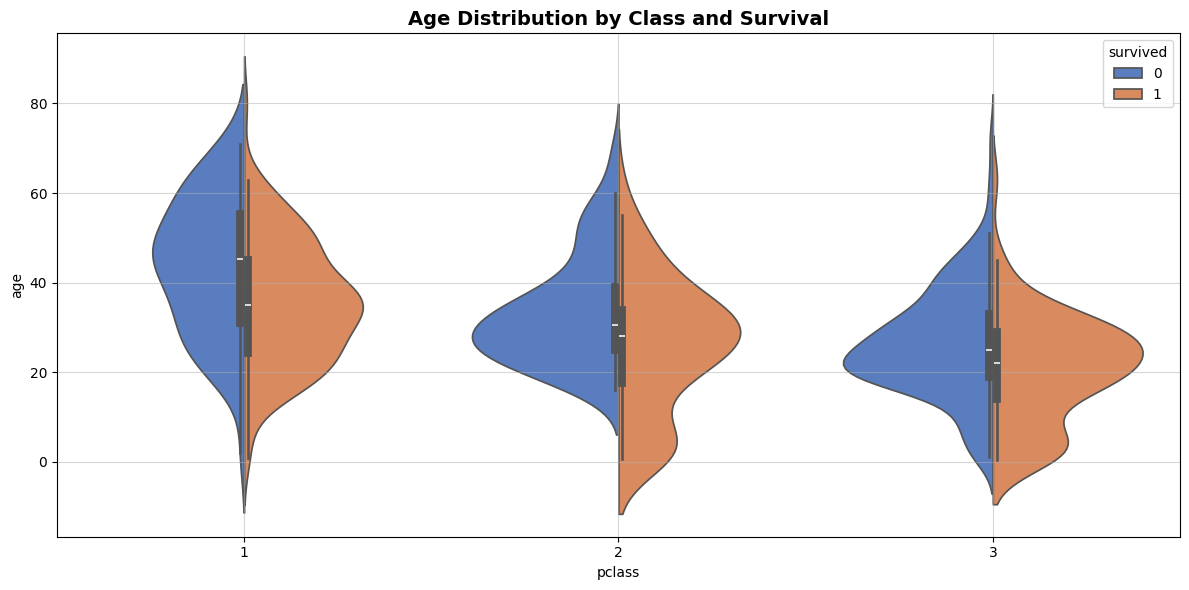

In [39]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="pclass", y="age",
               hue="survived",
               palette="muted",
               split=True)      # split=True shows both sides

plt.title("Age Distribution by Class and Survival",
          fontsize=14, fontweight="bold")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

C:\Temps\ipykernel_41724\3893432362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="fare",


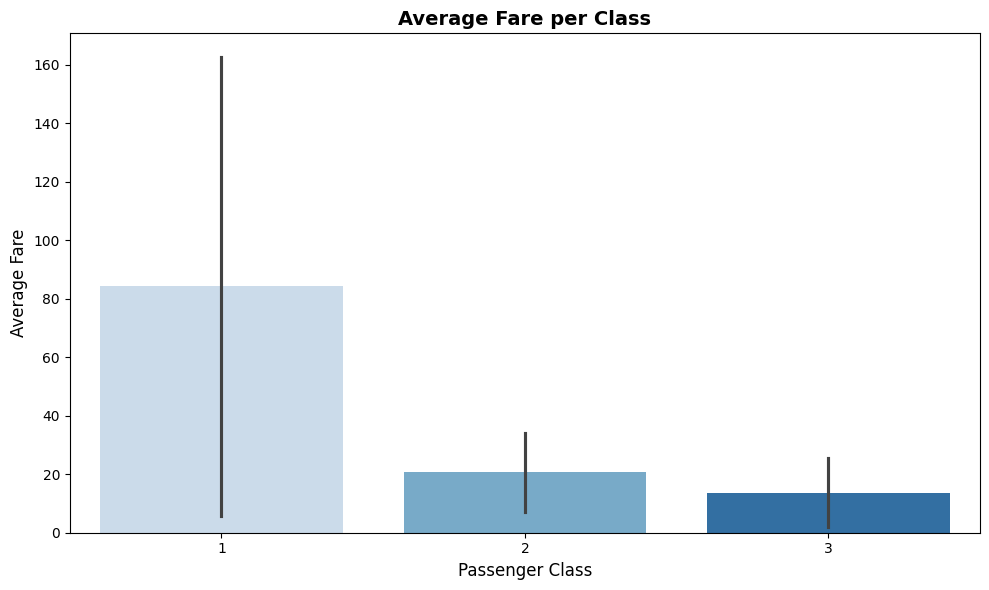

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="pclass", y="fare",
            palette="Blues",
            errorbar="sd")      # shows standard deviation

plt.title("Average Fare per Class",
          fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Average Fare", fontsize=12)
plt.tight_layout()
plt.show()

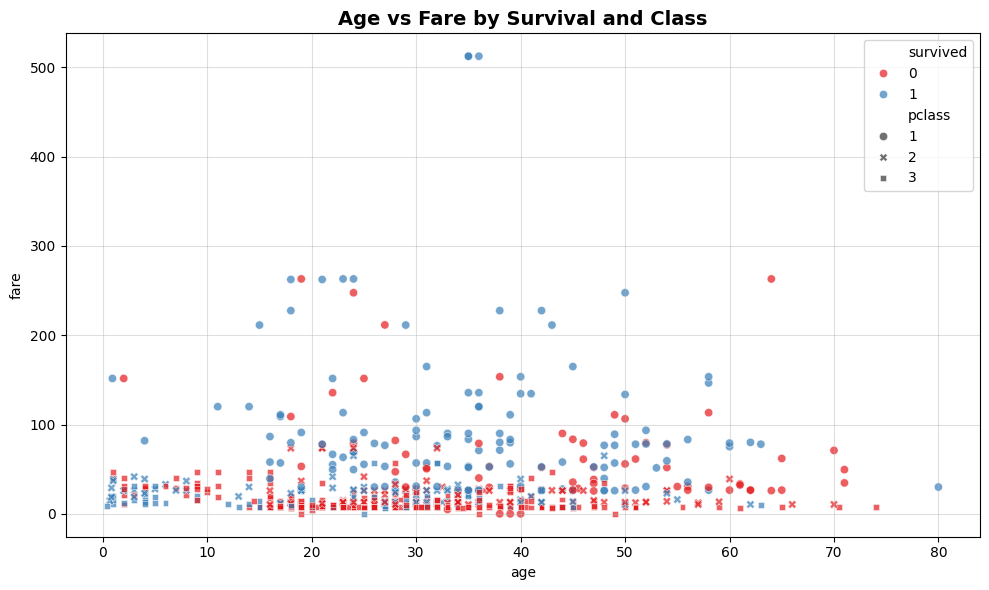

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="fare",
                hue="survived",    # color by survival
                style="pclass",    # shape by class
                palette="Set1",
                alpha=0.7)

plt.title("Age vs Fare by Survival and Class",
          fontsize=14, fontweight="bold")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

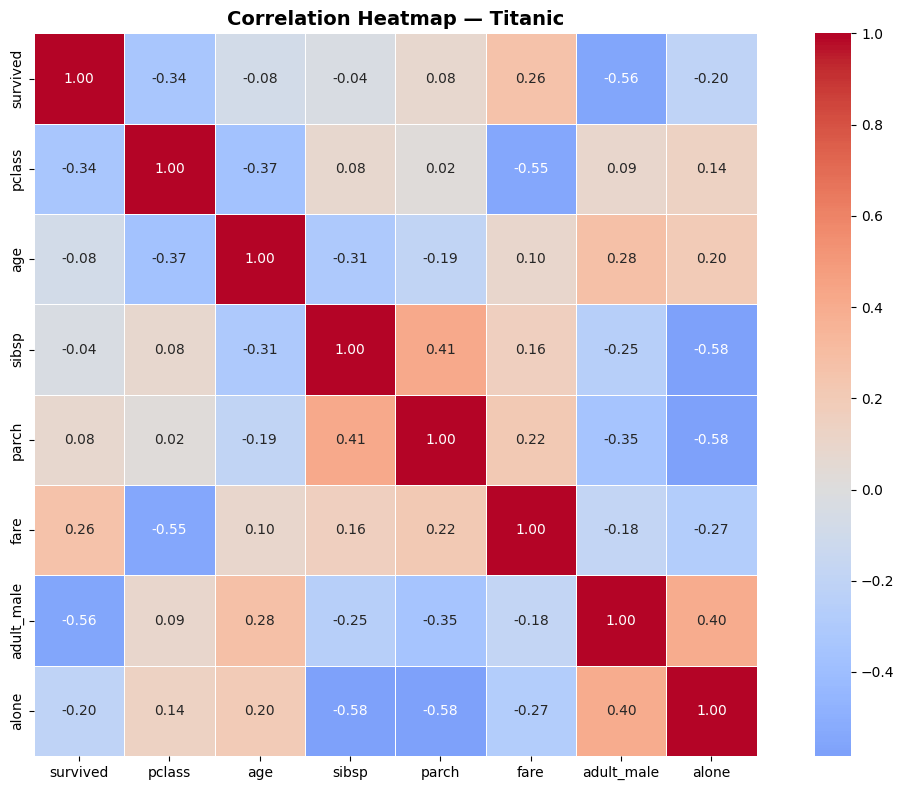

In [ ]:
plt.figure(figsize=(12, 8))

# Calculate correlation
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,          # show numbers in cells
            fmt=".2f",           # 2 decimal places
            cmap="coolwarm",     # red=positive, blue=negative
            center=0,            # white at 0
            square=True,         # square cells
            linewidths=0.5)      # lines between cells

plt.title("Correlation Heatmap — Titanic",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 📊 INSIGHT 1: Fare and Pclass strong negative correlation
#               Higher class number = lower fare
# 📊 INSIGHT 2: Survived correlates most with Fare and Pclass
#               These will be important ML features
# 📊 INSIGHT 3: Age has weak correlation with survival
#               Age alone was not a strong survival predictor

# **How to read the heatmap:**

# Value close to  1.0 = Strong positive relationship
# Value close to -1.0 = Strong negative relationship
# Value close to  0.0 = No relationship

# Color RED   = positive correlation
# Color BLUE  = negative correlation
# Color WHITE = no correlation

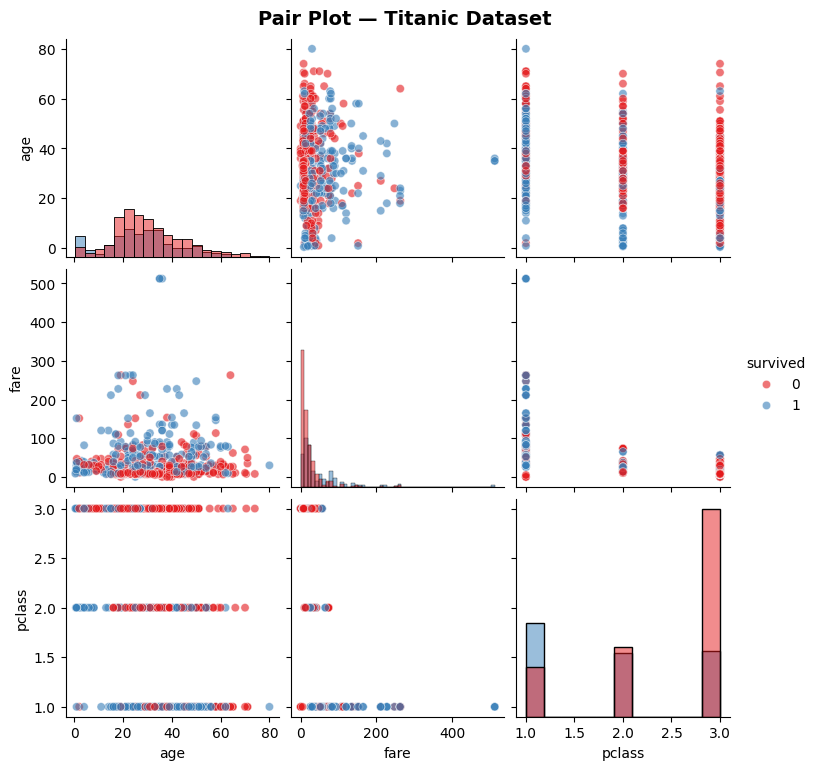

In [56]:
# Select relevant columns only
cols = ["age", "fare", "pclass", "survived"]

sns.pairplot(df[cols].dropna(),
             hue="survived",
             palette="Set1",
             diag_kind="hist",    # histogram on diagonal
             plot_kws={"alpha": 0.6})

plt.suptitle("Pair Plot — Titanic Dataset",
             y=1.02,
             fontsize=14,
             fontweight="bold")
plt.show()

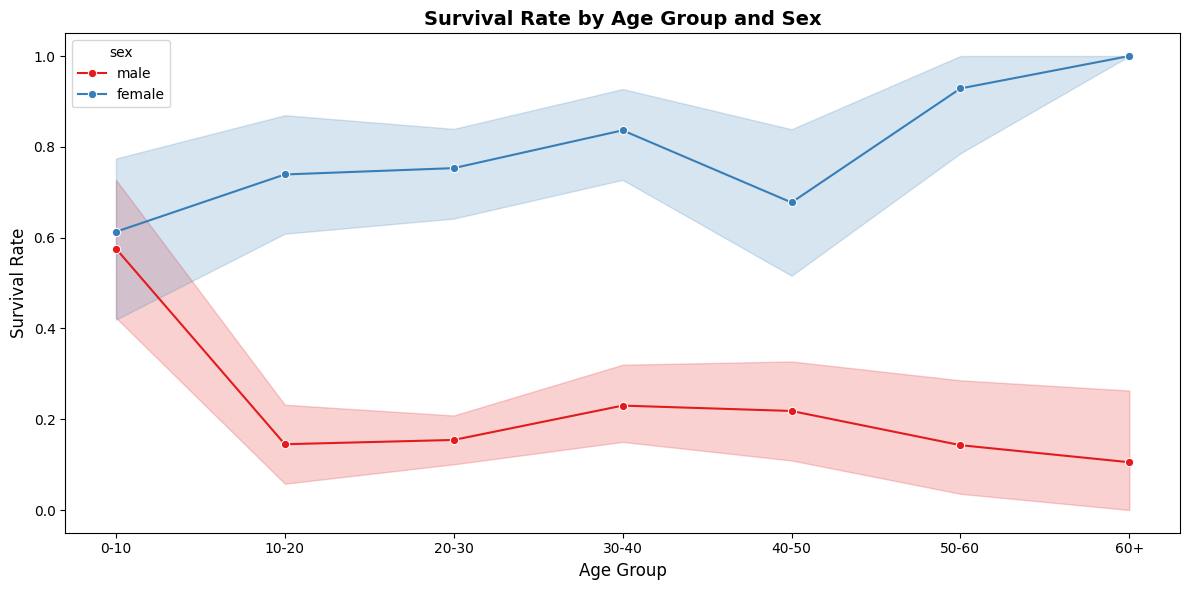

In [58]:
# Survival rate by age group
df["AgeGroup"] = pd.cut(df["age"],
                         bins=[0,10,20,30,40,50,60,80],
                         labels=["0-10","10-20","20-30",
                                 "30-40","40-50","50-60","60+"])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="AgeGroup",
             y="survived",
             hue="sex",
             marker="o",
             palette="Set1")

plt.title("Survival Rate by Age Group and Sex",
          fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Survival Rate", fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [62]:
!pip3 install kagglehub


   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   -------- -------------------------------  2/10 [pyyaml]
   -------- -------------------------------  2/10 [pyyaml]
  

# 🎬NETFLIX MOVIES DATASET EDA(VISUALIZATION)_PRACTICE -- SEABORN

In [120]:
import kagglehub

# Download latest version
df_netflix = pd.read_csv("netflix_titles.csv")

# print(df_netflix)
print(df_netflix.head(3))
print(df_netflix.shape)
print(df_netflix.columns.tolist())
print(df_netflix.dtypes)

  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water              NaN   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021          2021  TV-MA   1 Season   

                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas, TV Mysteries   
2  Crime TV Shows, International TV Shows, TV Act...   

                

In [102]:
# TOTAL ANALYSIS OF THE DATASET 

# STORY I OBSERVE FROM THE NETFLIX DATA
# the netflix data the story like the total movie data like director , released date , cast , rating , duration etc., finally this is the data of movies from 1925 to 2021 listed without budgets 
# some director names are missed a lot and not only director many things are missed , 
# rating is not in particular values, it is like different may it relates to regions like in india people give with values,
# duration also not in integers type it is in 90mins, 2 seasons , 3 seasons etc., i think this may be netflix calculations so,
# even dates also not in date format , they usually mentioned month , day , year - this format is good for easy finding the dates for human redable, not for  machines and calculation purpose,
# show id's also not in value format , this is different like beginning with s and values like s1, s2, s3 etc.


# BUSSINESS QUESTIONS FROM NETFLIX ANSWERED BY THIS DATA:-
# 1)which director had more movie rating,
# 2)Did duration of movie matters for people who are very lazy to watch the long duration movies,
# 3)which director is more popular , and people are prefering to watch there movies a lot,
# 4)Which genres are more popular watching by the people and which like they most ,
# 5)which type like movies or shows , did people prefer to watch more , they are showing interest to watch the movies or tvshows,
# 6)I think cast like popular heroes and actresses are also most important to grab the particular actor fans to watch the movies or shows,
# 7)which country movies getting high rating , 
# 8)Finally in my opinion, the target is like rating and genre, why means basically i am fan of prabhas but i watch every movies right not only prabhas movies , usually when i enter into the netflix i watch by rating and genre, if the rating is good i will watch movie and i like action genere i check the movies in action catergory and i watch those movie even checking by rating.
# THIS IS MY CONCLUSION OF THIS NETFLIX DATA


# type, country, release_year, rating(content), 
# duration, listed_in(genre), date_added

# What 5 interesting questions can you answer with JUST these columns?
# Don't think about what's missing. Think about what stories these columns CAN tell.
# For example — release_year goes from 1925 to 2021. What trend story could that tell about Netflix's content library?
# Think and tell me 3-5 questions. Then we build the Seaborn tasks around YOUR questions!

# 1)There are low Tv shows at old years like starting years , then people are prefering to watch the tv shows and then netflix also putting more interest in production of TV shows ,
# 2)Genre also increased a lot from since past to present , reason there were low technology at that time for making big action and adveunture movies , so gradually if more peopple are watching the action movies so production of making those movies also increased,
# 3)I think region based movies also include here , because indian movies are low in budget issues and there were no more CGI kind of things like avatar moive, so some kind of people alos prefer to watch the US movies, cuz they production quality is more better in CGI kind of effects may be,
# 4)Obviously duration of show matters a lot , reason past days people are watch movies for long duration also at any cost , but now many people are habitutated to the short form of content with low duration of movies due to many reasons like busy with the life , no time to watch the movies with hurry burry lifestyle, some bussiness peoples, software people etc.,
# 5)Tv shows and movies also matters here, cuz some people likes tv shows and may be some people with movies, usally i am alos with movies only not shows , they need to check this thing also

In [94]:
# duplicated = df_netflix['director'].duplicated()
# print(duplicated)

duplicated_direc = df_netflix[["title","director"]].loc[df_netflix["director"].duplicated()]
df_netflix['director'].value_counts()
# print(duplicated_direc)

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Mozez Singh                 1
Name: count, Length: 4528, dtype: int64

In [78]:
df_netflix.info()
df_netflix.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


CHECKING THE DATASET AND MISSING VALUES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

file_id = "1Jnjo4qd5WUqajOgauzOB7v4toJ7IR1w1"
url = f"https://drive.google.com/uc?id={file_id}"

df_netflix= pd.read_csv(url, encoding="latin1")
df_netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [4]:
# CHECKING THE MISSING VALUES FOR FILLING THE DATA

print("Missing values: -")
print(df_netflix.isnull().sum())
print("="*100)
print("Percentage of missin values:-")
print((df_netflix.isnull().sum() / len(df_netflix) * 100).round(2))
print("="*100)
print("Duplicates:-")
print(df_netflix.duplicated().sum())
print("="*100)
print(df_netflix.nunique())

Missing values: -
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Percentage of missin values:-
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64
Duplicates:-
0
show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64


In [5]:
# FILLING THE MISSING DATA

df_netflix['director'] = df_netflix['director'].fillna("Unknown")
df_netflix['cast'] = df_netflix['cast'].fillna("Unknown")
df_netflix['country'] = df_netflix['country'].fillna("Unknown")

df_netflix['date_added'] = df_netflix['date_added'].fillna(df_netflix['date_added'].mode()[0])

df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'].str.strip(), format='%B %d, %Y')

df_netflix['rating'] = df_netflix['rating'].fillna(df_netflix['rating'].mode()[0])

df_netflix['duration'] = df_netflix['duration'].fillna(df_netflix['duration'].mode()[0])



df_netflix.isnull().sum()

# df_netflix

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [6]:
print(df_netflix.isnull().sum())

print(df_netflix.dtypes)

print(df_netflix['date_added'].head(3))

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object
0   2021-09-25
1   2021-09-24
2   2021-09-24
Name: date_added, dtype: datetime64[us]


In [7]:
df_netflix['duration'].unique()
df_netflix['duration'].value_counts()
df_netflix['listed_in'].value_counts()
df_netflix['country'].value_counts()

country
United States                                    2818
India                                             972
Unknown                                           831
United Kingdom                                    419
Japan                                             245
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 749, dtype: int64

FEATURE ENGINEERING FOR THE DATASET

In [8]:
df_netflix['year_added'] = df_netflix['date_added'].dt.year

df_netflix['month_added'] = df_netflix['date_added'].dt.month

df_netflix['duration_num'] = df_netflix['duration'].str.extract("(\d+)").astype(float)

df_netflix['genre_count'] = df_netflix['listed_in'].str.count(",") + 1

df_netflix['country_main'] = df_netflix['country'].str.split(",").str[0].str.strip()

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Temps\ipykernel_24972\546292730.py:5: SyntaxWarning: invalid escape sequence '\d'
  df_netflix['duration_num'] = df_netflix['duration'].str.extract("(\d+)").astype(float)


In [9]:
print(df_netflix[["date_added","year_added","month_added",
                   "duration","duration_num",
                   "listed_in","genre_count",
                   "country_main"]].head())

  date_added  year_added  month_added   duration  duration_num  \
0 2021-09-25        2021            9     90 min          90.0   
1 2021-09-24        2021            9  2 Seasons           2.0   
2 2021-09-24        2021            9   1 Season           1.0   
3 2021-09-24        2021            9   1 Season           1.0   
4 2021-09-24        2021            9  2 Seasons           2.0   

                                           listed_in  genre_count  \
0                                      Documentaries            1   
1    International TV Shows, TV Dramas, TV Mysteries            3   
2  Crime TV Shows, International TV Shows, TV Act...            3   
3                             Docuseries, Reality TV            2   
4  International TV Shows, Romantic TV Shows, TV ...            3   

    country_main  
0  United States  
1   South Africa  
2        Unknown  
3        Unknown  
4          India  


In [10]:
print(df_netflix[["type", "release_year", "rating",
                   "duration_num", "genre_count",
                   "year_added", "month_added"]].describe())
print("="*100)
print("CONTENT TYPE SPLIT:-")
print(df_netflix['type'].value_counts(normalize=True).mul(100).round(2))
print("="*100)

print("TOP 10 COUNTRIES:")
print(df_netflix['country_main'].value_counts().head(10))
print("="*100)

print("\nTOP 10 RATINGS:")
print(df_netflix['rating'].value_counts().head(10))
print("="*100)

print("TOP 10 GENRES:")
print(df_netflix['listed_in'].str.split(",").str[0])
print("="*100)

print("\nCONTENT PER YEAR ADDED:")
print(df_netflix["year_added"].value_counts().sort_index())
print("="*100)

       release_year  duration_num  genre_count   year_added  month_added
count   8807.000000   8807.000000  8807.000000  8807.000000  8807.000000
mean    2014.180198     69.823436     2.194050  2018.873169     6.648575
std        8.819312     50.822055     0.784341     1.573808     3.439879
min     1925.000000      1.000000     1.000000  2008.000000     1.000000
25%     2013.000000      2.000000     2.000000  2018.000000     4.000000
50%     2017.000000     88.000000     2.000000  2019.000000     7.000000
75%     2019.000000    106.000000     3.000000  2020.000000    10.000000
max     2021.000000    312.000000     3.000000  2021.000000    12.000000
CONTENT TYPE SPLIT:-
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64
TOP 10 COUNTRIES:
country_main
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico      

In [ ]:
# INSIGHT QUESTIONS OF NETFLIX STORY AFTER FEATURE ENGINEERNG

# 69% of movies are dominating the tv shows in netflix , so movies are high priority in netflix bussiness
# yeah obviously , US had highest movies count while comparing to other countries ,so more movies are coming from the US only , so that is the reason may be rating also in US standards may be
# 2019 year had more content in netflix which is impeccable 2026 content , i don't know exaclty reason about the bussiness of netflix , may be if we look into the plots or EDA we can find that if ii am not wrong

In [33]:
df_movies = df_netflix[df_netflix['type'] == 'Movie']
df_tvshows = df_netflix[df_netflix['type'] == 'TV Show']

print("Movie duration stats:-")
print(df_movies['duration_num'].describe())
print("="*100)

print("TV shows duration stats:-")
print(df_tvshows['duration_num'].describe())
print("="*100)

print("\nContent added by year:")
print(df_netflix.groupby(["year_added","type"])
      .size().unstack().fillna(0).astype(int))

         
# print(df_movies.head(3))
# print("="*100)
# print(df_tvshows)

Movie duration stats:-
count    6131.000000
mean       99.528951
std        28.367576
min         1.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64
TV shows duration stats:-
count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_num, dtype: float64

Content added by year:
type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      176
2017          839      349
2018         1237      412
2019         1424      592
2020         1284      605
2021          993      505


VISUALIZATION PROCESS STARTED 

C:\Temps\ipykernel_24972\3822943626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_netflix ,x = 'type', palette='Set1', edgecolor='black')


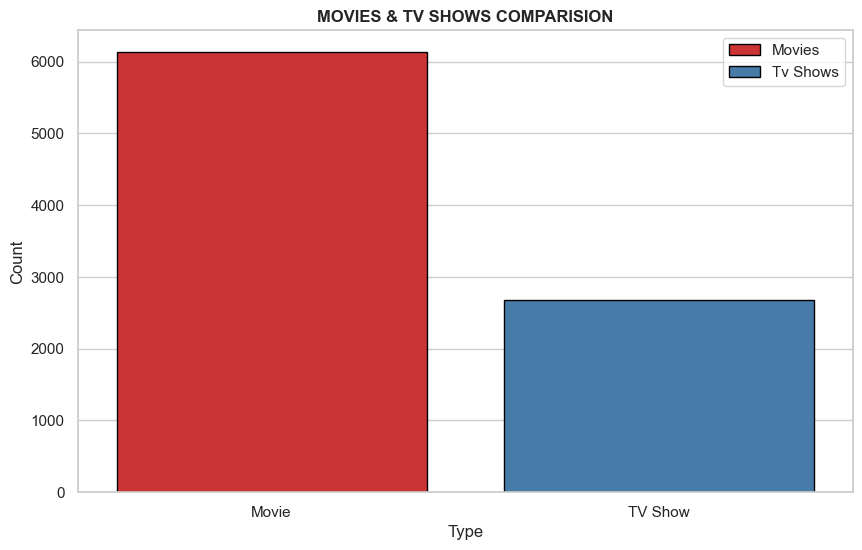

In [60]:
# TASK - 1

plt.figure(figsize=(10,6))

sns.countplot(data=df_netflix ,x = 'type', palette='Set1', edgecolor='black')

plt.title("MOVIES & TV SHOWS COMPARISION",fontweight = 'bold')
plt.xlabel("Type")
plt.ylabel("Count")
plt.legend(["Movies" , "Tv Shows"])

plt.tight_layout()
plt.show()

# movies are 6000 more comparing to tv shows (around 2800)
# netflix is getting more bussiness through movies 
# movies is more kk , when comparing to length time we can get tvshows because we can calculate seasons as 1 , 2, 3 etc, so we can get more legth of time than movies

C:\Temps\ipykernel_24972\2163412240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='type', data=df_netflix, palette=['#E50914', '#221f1f'], edgecolor='black')


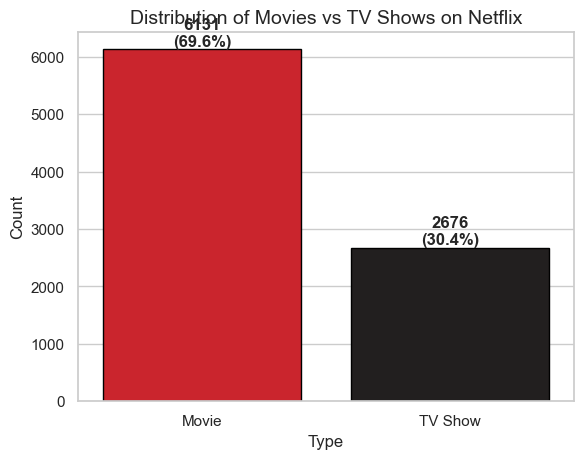

In [70]:
# SHOWING THE PERCENTAGE TOP OF THE BARS

import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='type', data=df_netflix, palette=['#E50914', '#221f1f'], edgecolor='black')

# Add count and percentage labels on top of bars
total = len(df_netflix)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(f'{count}\n({percentage})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


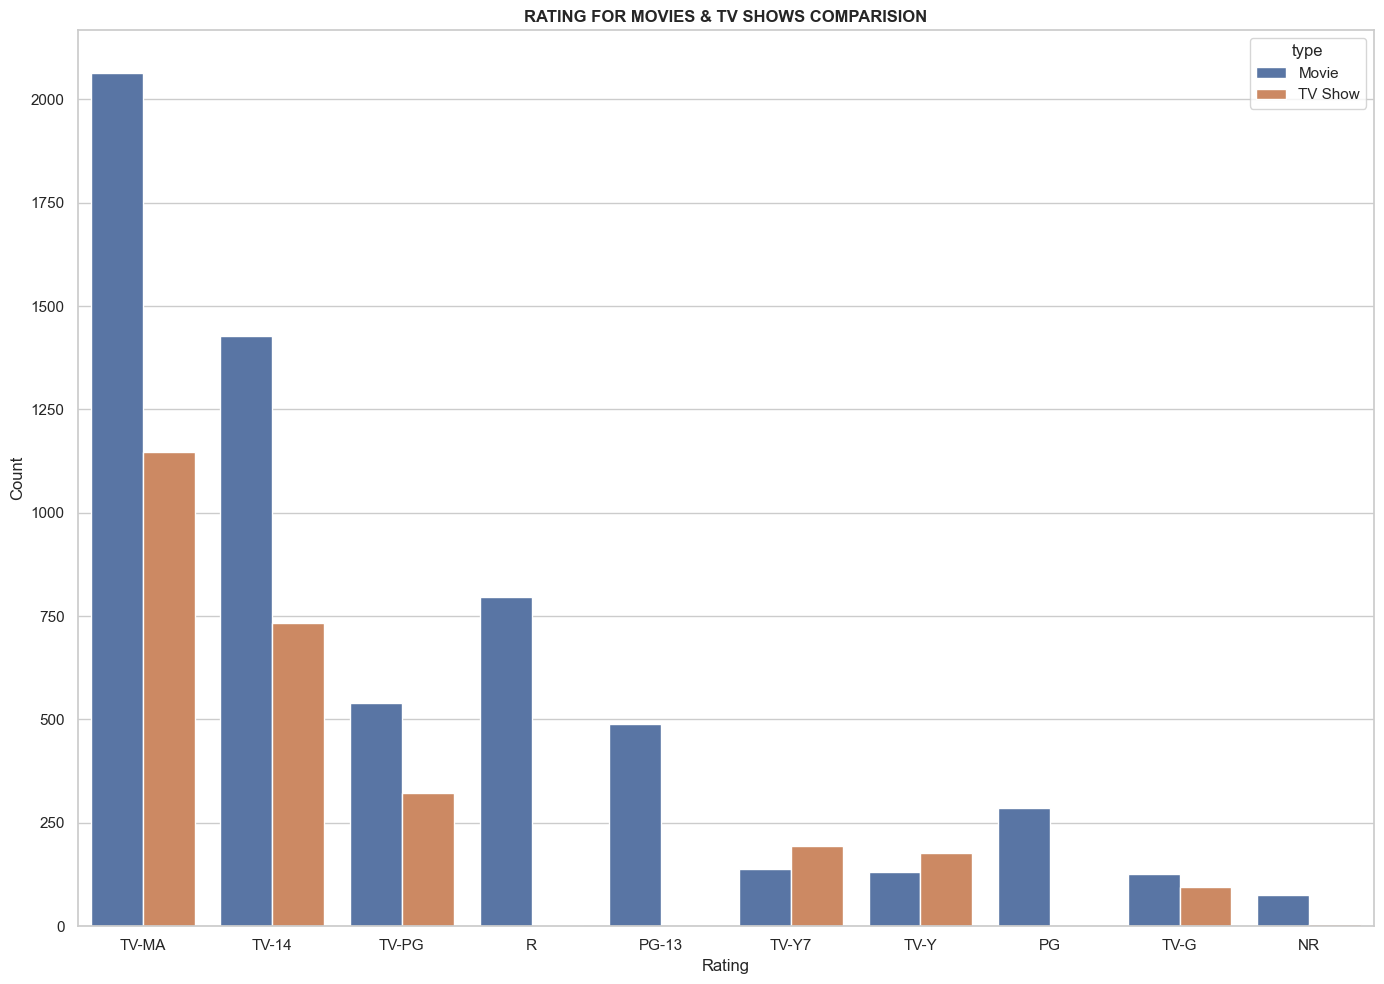

In [122]:
# TASK - 2

top_ratings = df_netflix[
    df_netflix["rating"].isin(
    df_netflix["rating"].value_counts().head(10).index)]

plt.figure(figsize=(14,10))
sns.countplot(data=df_netflix, x='rating', hue='type', order=df_netflix["rating"].value_counts().head(10).index)

plt.title("RATING FOR MOVIES & TV SHOWS COMPARISION",fontweight = 'bold')
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.show()
# df_netflix
# print(df_netflix['rating'].unique())

# rating for movies are more high comparing to the TV shows due to more no.of movies are there
# Usually netflix is targeting the adults people of TV MA , 
# There are no rating for TVshows in the rating sector for PG,PG-13, R , NR, i don't know why the reason is i think there is no tvshows in those rating section 

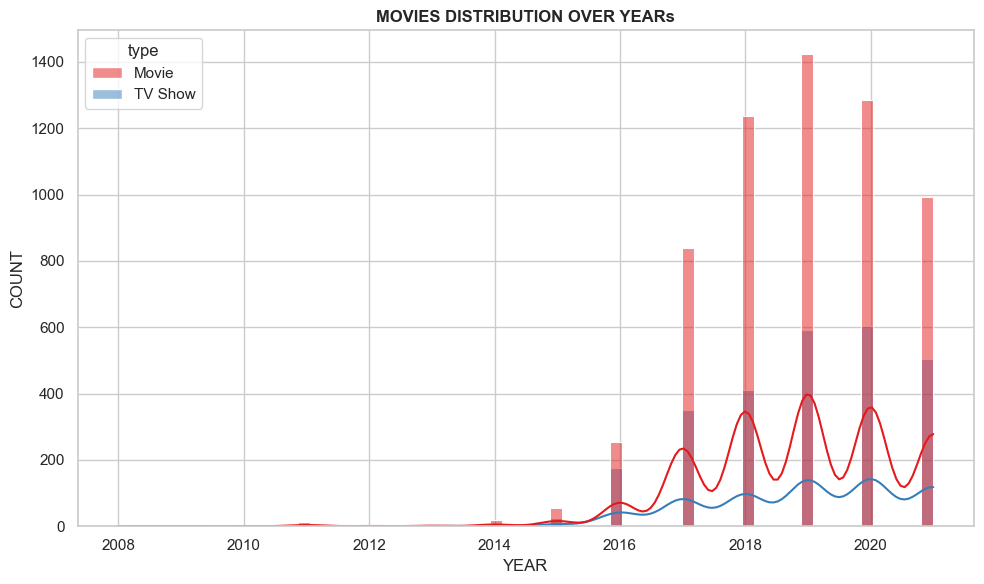

In [123]:
# TASK - 3

plt.figure(figsize=(10,6))

sns.histplot(data = df_netflix,x='year_added', hue='type', kde=True, palette='Set1')

plt.title("MOVIES DISTRIBUTION OVER YEARs",fontweight = 'bold')
plt.xlabel("YEAR")
plt.ylabel("COUNT")

plt.tight_layout()
plt.show()

# The netflix came into the picture at 2016, i think many people noticed about netflix
# But Netflix can increased and spread over the world like boom at 2017 - 2021 and still getting high
# 2019 year highest recorded distribution of netflix , i think people we addicted to netflix with this hightime 

C:\Temps\ipykernel_24972\1237533314.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,  y= top_countries.index , palette="Blues_r")


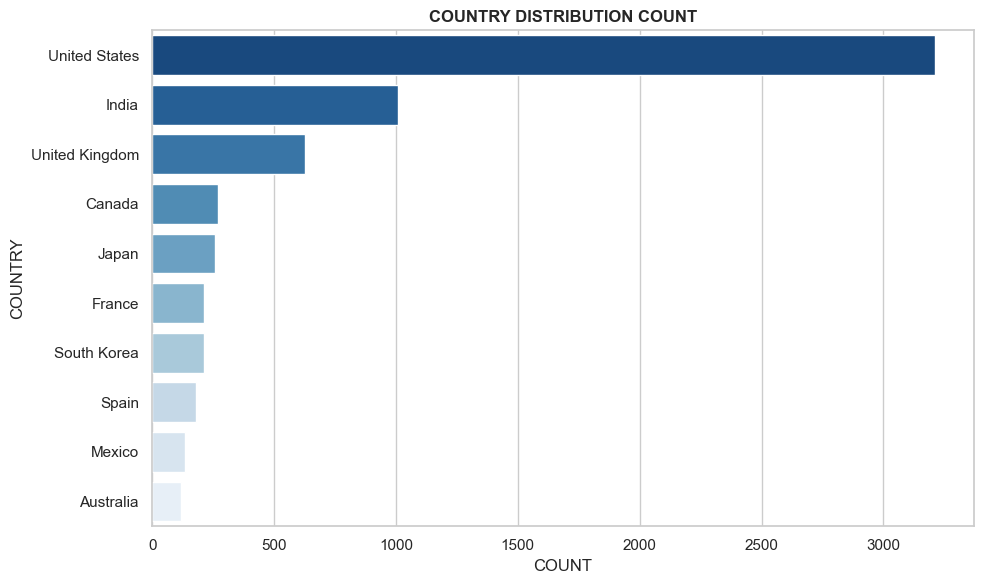

In [140]:
# TASK - 4

top_countries = df_netflix[df_netflix["country_main"] != "Unknown"]["country_main"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_countries.values,  y= top_countries.index , palette="Blues_r")

plt.title("COUNTRY DISTRIBUTION COUNT",fontweight = 'bold')
plt.xlabel("COUNT")
plt.ylabel("COUNTRY")

plt.tight_layout()
plt.show()

# US is making the most movies into netflix that very impecable count, where no other countries  not even close to the US
# INDIA is the second country making more movies in to the netflix , this surprise me, i didnt even think india is having second place to make movies 


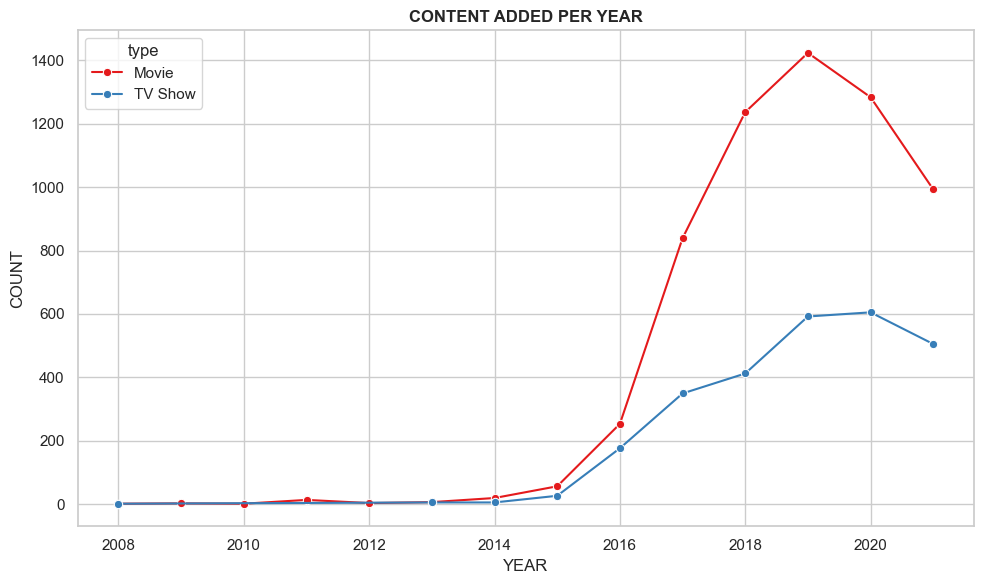

In [ ]:
# TASK - 5

yearly = df_netflix.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(10,6))

sns.lineplot(data=yearly,
             x="year_added",
             y="count",
             hue="type",
             marker="o",
             palette="Set1")

plt.title("CONTENT ADDED PER YEAR",fontweight = 'bold')
plt.xlabel("YEAR")
plt.ylabel("COUNT")

plt.tight_layout()
plt.show()
# print(yearly)
# 1) Which year had peak content?
# obviosly 2019 had best peak content added due to people were show more interested netflix , becasue it reaches to every corner of te world due to pandemic , so anxiety were increased to explore and watch movies in netflix so this is teh reason that is the peak year and covid-19 pandemic started every people were sticked into the houses , then the option is to watch movies ,this is the main reason for peakc content.

# 2) What happened after 2019?
# it decreases little bit , because pandemic ended in the final year of 2020 , but it didn't fall very drastically due people habitutated to the movies watching netflix through OTT, very easy and lazy way.


C:\Temps\ipykernel_24972\2590645525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_movies , x = 'rating', y='duration_num', palette='Set3')


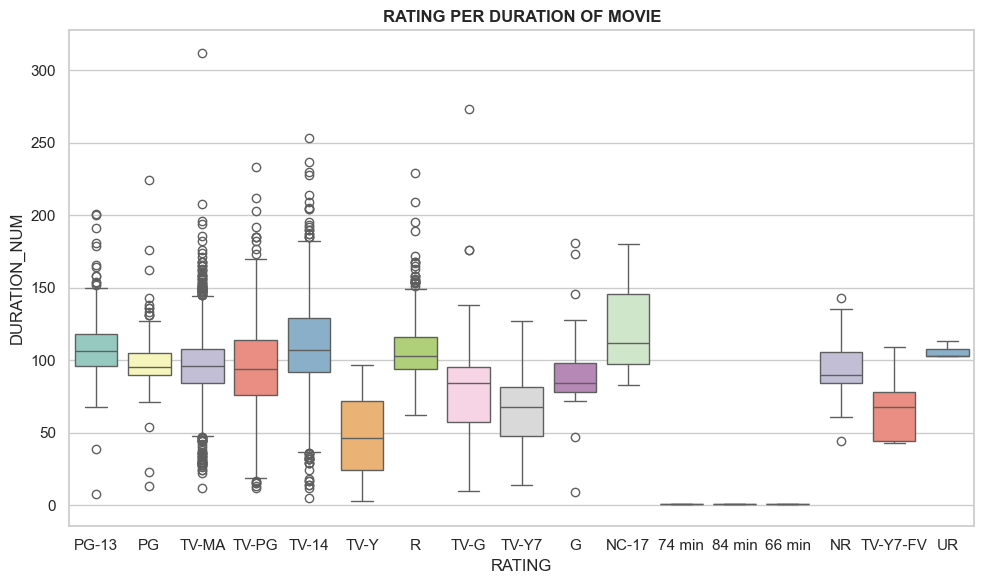

In [ ]:
# TASK- 6

plt.figure(figsize=(10,6))

sns.boxplot(data=df_movies , x = 'rating', y='duration_num', palette='Set3')
plt.title("RATING PER DURATION OF MOVIE",fontweight = 'bold')
plt.xlabel("RATING")
plt.ylabel("DURATION_NUM")

plt.tight_layout()
plt.show()

# it completely false statement, higher rated movies doesn't not run longer according to rating 
# Averagely the duration is around lying between the 100 only,
# There is lot of outliers in all rating sections , and which i cant believe is that 320 mins😂 may be there should be a documnentry kind of content, anyway there are lot of outliers passing in almsot all rating sections


C:\Temps\ipykernel_24972\3061218687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tvshows , x = 'rating', y = 'duration_num', palette='Set2')


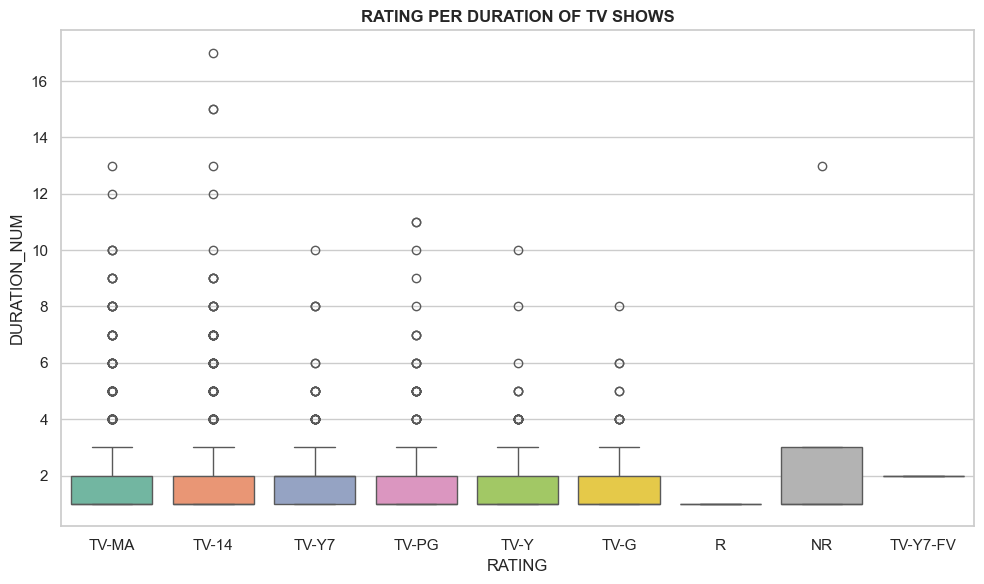

In [161]:
# TASK - 7

plt.figure(figsize=(10,6))

sns.boxplot(data=df_tvshows , x = 'rating', y = 'duration_num', palette='Set2')

plt.title("RATING PER DURATION OF TV SHOWS",fontweight = 'bold')
plt.xlabel("RATING")
plt.ylabel("DURATION_NUM")

plt.tight_layout()
plt.show()

# according to this , TV-14 is producing longest running TV shows in Netflix
# The outlier also appear in the TV-14 only but this is the key one to notice, because it is having 17 seasons which is very longest running streaming mins, this is important outlier

C:\Temps\ipykernel_24972\3208931393.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genres, x ='count', y = 'genre', edgecolor = 'black', palette='viridis')


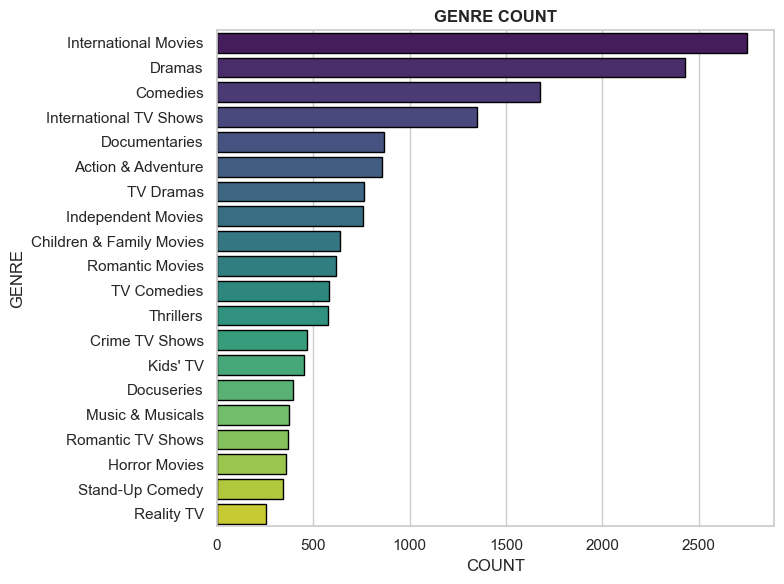

In [ ]:
# TASK - 8

genres = df_netflix['listed_in'].str.split(", ").explode().value_counts().reset_index().head(20)
genres.columns = ["genre", "count"]

plt.figure(figsize=(8,6))

sns.barplot(data=genres, x ='count', y = 'genre', edgecolor = 'black', palette='viridis')

plt.title("GENRE COUNT",fontweight = 'bold')
plt.xlabel("COUNT")
plt.ylabel("GENRE")

plt.tight_layout()
plt.show()
# print(genres)

# International movies are more domination over all genres, it is huge 
# Drama movies are the second one which is very close to the international movies
# No it didn't match my prediction , basically i think action & adveture movies are more, it didn't even the top 5 also , anyways it surprises me that's ok

Text(0.5, 1.0, 'CORREALATION OF NETFLIX DATA')

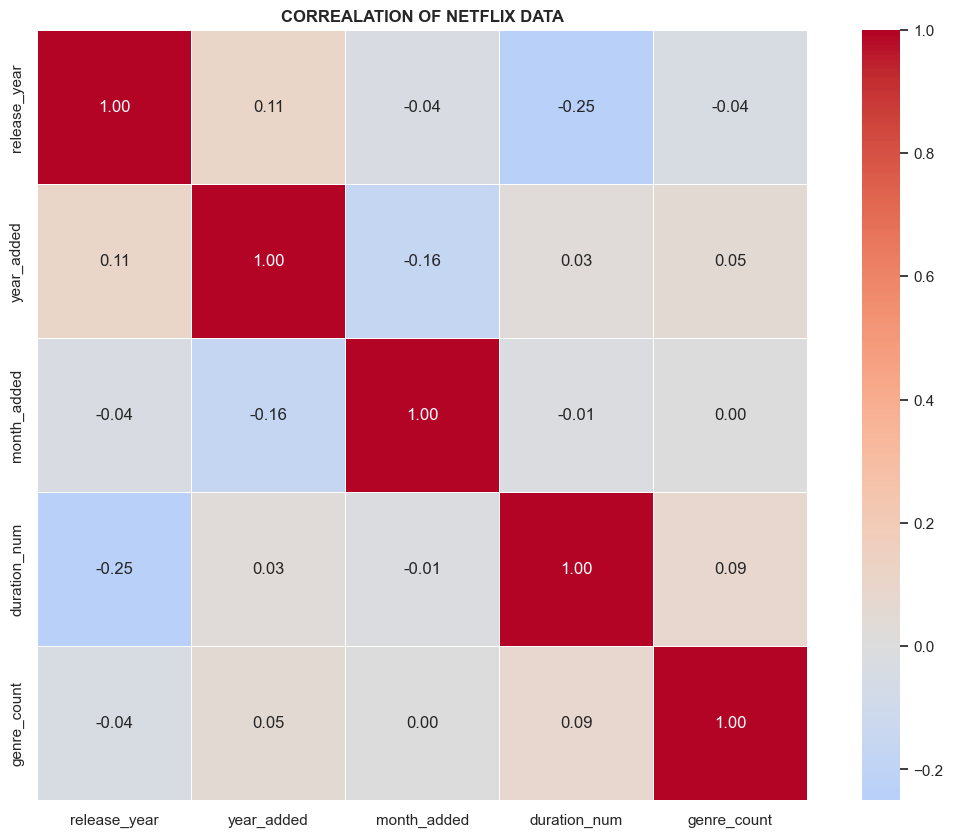

In [ ]:
# TASK - 9

plt.figure(figsize=(14,10))

correlation = df_netflix.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,          # show numbers in cells
            fmt=".2f",           # 2 decimal places
            cmap="coolwarm",     # red=positive, blue=negative
            center=0,            # white at 0
            square=True,         # square cells
            linewidths=0.5,)     # lines between cells

plt.title("CORREALATION OF NETFLIX DATA", fontweight='bold')


# There is little bit correlation in duration_num and release_year which is -0.25 Negative correlation
# There no other have the strong correlations on this data, almost they are lies in 0.02,0.04 like this, so we can say there are no strong correations ,
# There is nothing surprises me here, i surprised for nothing correlations that's it.

C:\Temps\ipykernel_24972\2009604775.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_netflix ,x = 'type', palette='Set1', edgecolor='black')
C:\Temps\ipykernel_24972\2009604775.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genres, x ='count', y = 'genre', edgecolor = 'black', palette='viridis')


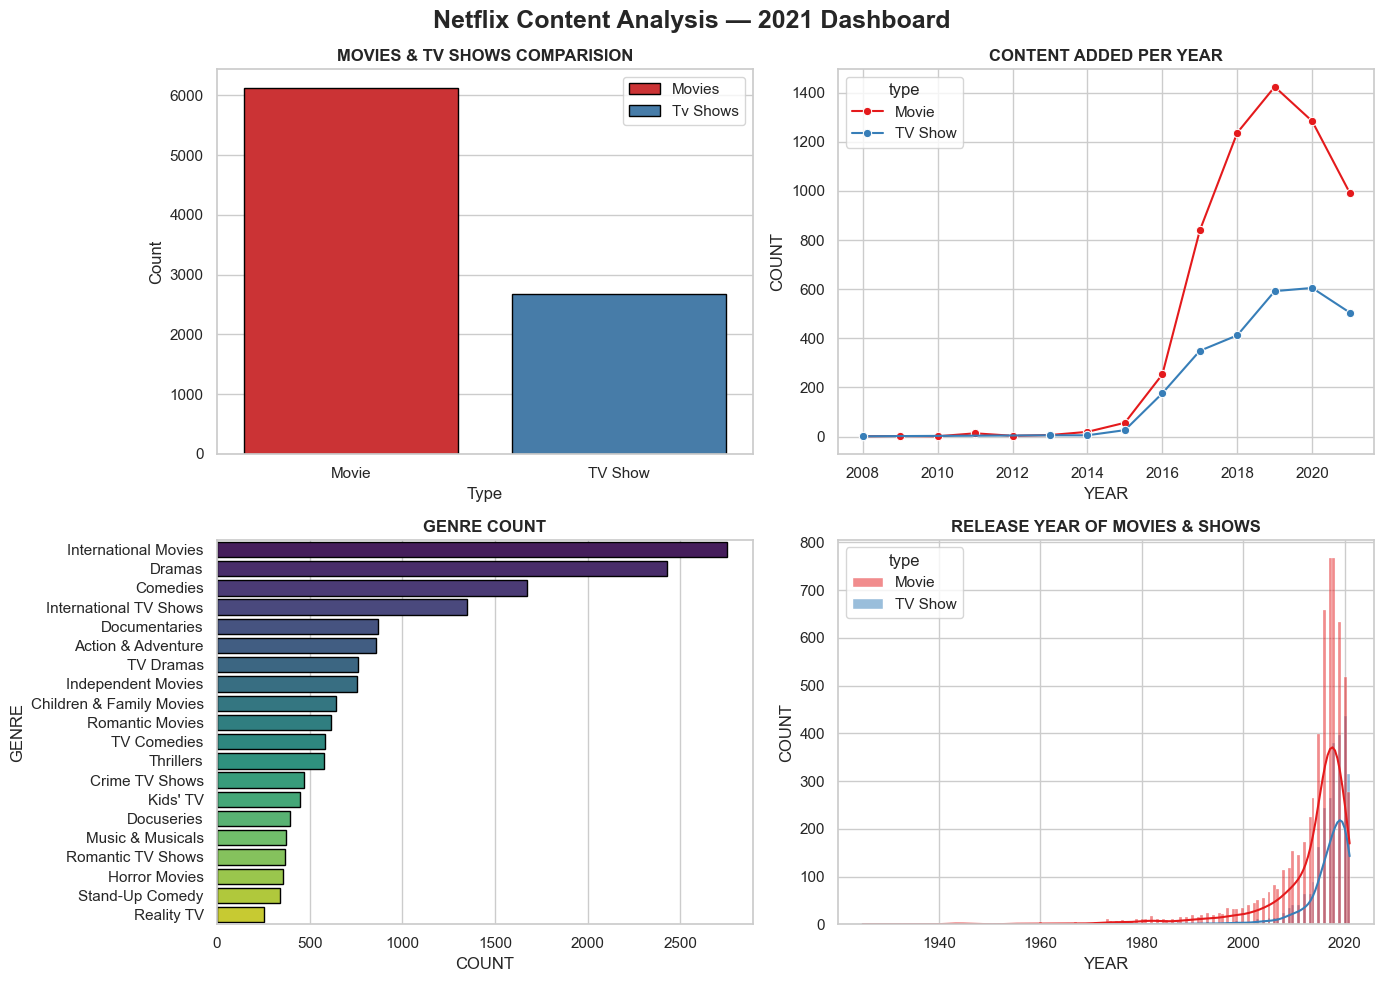

In [ ]:
# TASK - 10


# cols = ["release_year", "duration_num",
#         "genre_count", "year_added", "type"]
# plt.figure(figsize=(14,10))
# sns.pairplot(df_netflix[cols].dropna(),
#              hue="type",
#              palette="Set1",
#              diag_kind="hist",
#              plot_kws={"alpha": 0.5})

# plt.suptitle("Netflix — Pairplot by Content Type",
#              y=1.02,
#              fontsize=14,
#              fontweight="bold")
# plt.show()

# TASK 10 — Full 2x2 Dashboard
# Top left:    countplot type
# Top right:   lineplot yearly trend by type
# Bottom left: barplot top 10 countries
# Bottom right: histplot release_year by type
# Main title: "Netflix Content Analysis — 2021"
# Write 4 insights — one per chart

plt.figure(figsize=(14, 10))
plt.suptitle("Netflix Content Analysis — 2021 Dashboard", fontsize=18, fontweight="bold")

# Top left
plt.subplot(2, 2, 1)
sns.countplot(data=df_netflix ,x = 'type', palette='Set1', edgecolor='black')

plt.title("MOVIES & TV SHOWS COMPARISION",fontweight = 'bold')
plt.xlabel("Type")
plt.ylabel("Count")
plt.legend(["Movies" , "Tv Shows"])

# Top right
plt.subplot(2, 2, 2)
sns.lineplot(data=yearly,
             x="year_added",
             y="count",
             hue="type",
             marker="o",
             palette="Set1")

plt.title("CONTENT ADDED PER YEAR",fontweight = 'bold')
plt.xlabel("YEAR")
plt.ylabel("COUNT")

# Bottom left
plt.subplot(2, 2, 3)
sns.barplot(data=genres, x ='count', y = 'genre', edgecolor = 'black', palette='viridis')

plt.title("GENRE COUNT",fontweight = 'bold')
plt.xlabel("COUNT")
plt.ylabel("GENRE")


# # Bottom right
plt.subplot(2, 2, 4)
sns.histplot(data = df_netflix,x='release_year', hue='type', kde=True, palette='Set1')

plt.title("RELEASE YEAR OF MOVIES & SHOWS",fontweight = 'bold')
plt.xlabel("RELEASE_YEAR")
plt.ylabel("COUNT")

plt.tight_layout()
plt.show()


# There are more movies comparing to the tv shows , there is lot gap between movies and shows
# Netflix usage higly increased 2017 to 2021, the highest peak is at 2019 adn decreased little bit after 19 , we already discussed about this thing previously
# International movies genre are more comparing to remaining ones, due to every nation moveis are there in netflix right , this one alos discussed before
# when the netflix came into  the picture  , the release year of movies increases a lot comparing to before, netflix plays a key role for movies releses


In [ ]:
# INSIGHTS PRESENTING TO THE NETFLIX

# 1. What type of content dominates Netflix 
#    and what does this mean for business?
# Movies content dominates in the netflix , so many people are showing interest in the netflix so netflix should put more interest in movies rather than the TV shows.
# As usual we can improve the bussiness also for movies production , 
# Main important thing, movies are in high domination in netflix, it not means tv shows doesn't it is a 30% of content in netflix , so we also put more interest in tv shows production also to equalize with movies. 

# 2. Which country should Netflix invest 
#    more in for future growth — and why?
# US is already in higher position in production of content so it is already producing more movies , i didn't recommend to invest in US for future growth,
# I would recommend to invest in India for future growth , cuz india is slowly growing in production of movies in netflix so if we put more investment in india it will bring more profits for netflix.top_countries

# 3. What does the 2019 peak and 2020 drop 
#    tell Netflix about their content strategy?
# Basically the netflix is slowy getting popular after 2017 and then people noticed the netflix and start watching the content inthe netflix and when netflix is observed that , they started to add teh more movies in netflix and people also engaged in 2019 , and then people habituated to the netflix slowly watching the contetnt in the netflix drops at 2020, so i think this is the reason
# First notice which genre is booming in watching the content in netflix, and apart from the international movies , second one is dramas , so we recommend dramas genre in top priority in the lnading page and similarly like other genres also , and if netflix  produce top genre movies it would be more profitable because watching the content is become more and peopele trust the netflix like "it is a netflix one and i think it is the best film so we should watch it" , this works 

# 4. Which genre should Netflix produce 
#    more original content in — and why?
# Dramas , cuz dramas are holding second most watching genre in netflix so netflix must produce on dramas as usual to remaining genres also

# 5. One thing that SURPRISED you in this 
#    entire analysis that you didn't expect?
# As i told you before India surprises me for holding teh second position in countries of high content generating, i didn't even expect that india is genereating the that much content in netflix

In [159]:
df_netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num,genre_count,country_main
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0,1,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2.0,3,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1.0,3,Unknown
